In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [78]:
df_hurr = pd.read_csv('/Users/Local/hurricanes.csv')
df_hurr.head()
df_hurr.shape

(127649, 61)

In [79]:
df_hurr.columns = df_hurr.columns.str.lower()

### attribute selection

In [81]:
df_hurr['datetime'] =pd.to_datetime(df_hurr['iso_time'])
df_hurr['date'] = df_hurr['datetime'].dt.floor('D')

df = df_hurr[["name", 'nature', "date", "lat", 'lon', 'wmo_wind', 'dist2land', 'landfall', 'usa_sshs', 'storm_speed', 'usa_roci']]

df['date'].dtype

dtype('<M8[ns]')

### numerosity reduction

In [82]:
df = df[(df["name"] != "UNNAMED") & 
        (df["date"].dt.year > 2020) & 
        (df["date"].dt.year < 2026)]


df.shape

hurr_df = df.copy

#### integration

In [83]:
path = "/Users/Local/HurricanesAndGasPrices/Data/gas_days_geo.csv"
gas_df = pd.read_csv(path)
gas_df.head()
gas_df['date'] = pd.to_datetime(gas_df['date']).dt.floor("D")

In [84]:
df['lat'].dtype
#gas_df['lat'].dtype

dtype('float64')

In [85]:
max_lat = gas_df['lat'].max()
min_lat = gas_df['lat'].min()

max_lng = gas_df['lng'].max()
min_lng = gas_df['lng'].min()

df = df[(df["lat"] < max_lat) & (df["lat"] > min_lat) & 
        (df["lon"] < max_lng) & (df["lon"] > min_lng)]

df.shape

(100, 11)

> Attach hurricane data if it is over a certain metro by how many km?

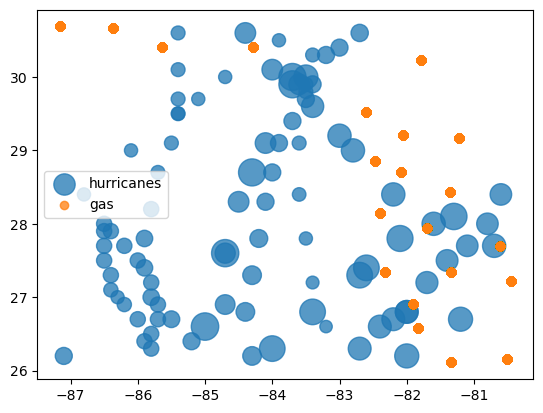

In [89]:
plt.scatter(df['lon'], df['lat'], 
            label = "hurricanes",
            alpha = .75,
            s = df['usa_roci'])

plt.scatter(gas_df['lng'], gas_df['lat'], 
            label = "gas",
            alpha = .75)

plt.legend()